In [1]:
import sys
from pathlib import Path

# Add src/ to sys.path regardless of where Jupyter is launched from
for _candidate in [Path().resolve().parent / "src", Path().resolve() / "src"]:
    if _candidate.exists() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        print(f"Added to sys.path: {_candidate}")
        break

Added to sys.path: C:\Users\loren\Documents\Postdoc\Compressed_sensing\compressed_sensing_bioacoustics\src


In [2]:
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt

from bats_dataset_creator import BatsDatasetCreator
from settings import Config
from config_species import get_settings

In [3]:
import importlib
import bats_dataset_creator
importlib.reload(bats_dataset_creator)
from bats_dataset_creator import BatsDatasetCreator

In [4]:
selected_species = "bats" #"thyolo" # gibbon / ptw
settings = get_settings(selected_species)
config = Config(settings) # Pass settings to your config object

In [5]:
print(config.preprocessing.dict())

{'sample_rate': 256000, 'lowpass_cutoff': 2000, 'downsample_rate': 128000, 'nyquist_rate': 2400, 'segment_duration': 4, 'nb_negative_class': 20, 'annotation_extension': '.svl', 'audio_extension': '.wav', 'n_fft': 512, 'hop_length': 384, 'n_mels': 128, 'f_min': 15000, 'f_max': 64000}


In [6]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BATS_ROOT   = Path("C:/Users/loren/Documents/Postdoc/Compressed_sensing/Data/Bats")
AUDIO_PATH  = BATS_ROOT / "Audio"
TRAIN_TXT   = BATS_ROOT / "DataFiles" / "train.txt"
TEST_TXT    = BATS_ROOT / "DataFiles" / "test.txt"
LABEL_MAP   = BATS_ROOT / "labelName_to_labelInd_bats_UFS.json"
FILTERS_DIR = Path("../bats_filters")   # relative to notebooks/
OUTPUT_PATH = BATS_ROOT

# ── Compression (None = standard .wav pipeline) ───────────────────────────────
METHOD_COMPRESSION    = "cs"  # e.g. None, "flac", "cs"
PARAMETER_COMPRESSION = 0.2  # e.g. None, 0, 0.15

# Spectrogram/audio parameters come from config.preprocessing.dict()

In [7]:
creator = BatsDatasetCreator(
    audio_path=AUDIO_PATH,
    train_txt=TRAIN_TXT,
    test_txt=TEST_TXT,
    label_map_path=LABEL_MAP,
    filters_path=FILTERS_DIR,
    method_compression=METHOD_COMPRESSION,
    parameter_compression=PARAMETER_COMPRESSION,
    **config.preprocessing.dict(),
)
print("Label map:", creator.label_map)

Label map: {'CISTUGO': 0, 'CNEHOT': 1, 'LAECAP': 2, 'TADAEG': 3}


In [8]:
X_train, Y_train = creator.create_training_dataset()
print(f"\nTraining set — X: {X_train.shape}, Y: {Y_train.shape}")
print("Class distribution:", dict(zip(*np.unique(Y_train, return_counts=True))))

creator.save_dataset(X_train, Y_train, OUTPUT_PATH, "train")

Loading train.txt:   0%|          | 0/2314 [00:00<?, ?it/s]

Loading train.txt: 100%|██████████| 2314/2314 [01:41<00:00, 22.88it/s]


Before balancing: 20786 windows — {'CISTUGO': 1721, 'CNEHOT': 1631, 'LAECAP': 14456, 'TADAEG': 2978}
After  balancing: 7352 windows — {np.int64(0): np.int64(1721), np.int64(1): np.int64(1631), np.int64(2): np.int64(2000), np.int64(3): np.int64(2000)}
After  mask:      5045 windows — {np.int64(0): np.int64(1343), np.int64(1): np.int64(605), np.int64(2): np.int64(1628), np.int64(3): np.int64(1469)}


Spectrograms: 100%|██████████| 5045/5045 [00:15<00:00, 325.94it/s]



Training set — X: (5045, 128, 334), Y: (5045,)
Class distribution: {np.int64(0): np.int64(1343), np.int64(1): np.int64(605), np.int64(2): np.int64(1628), np.int64(3): np.int64(1469)}
Saved → C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Bats\train\bats_X_train_cs_0.2.pkl
Saved → C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Bats\train\bats_Y_train_cs_0.2.pkl


In [13]:
X_test, Y_test = creator.create_testing_dataset()
print(f"\nTesting set — X: {X_test.shape}, Y: {Y_test.shape}")
print("Class distribution:", dict(zip(*np.unique(Y_test, return_counts=True))))

creator.save_dataset(X_test, Y_test, OUTPUT_PATH, "test")

Loading test.txt:   0%|          | 0/1017 [00:00<?, ?it/s]

Loading test.txt: 100%|██████████| 1017/1017 [00:44<00:00, 22.87it/s]


Before mask: 11723 windows — {np.int64(0): np.int64(898), np.int64(1): np.int64(956), np.int64(2): np.int64(8342), np.int64(3): np.int64(1527)}
After mask: 9131 windows — {np.int64(0): np.int64(679), np.int64(1): np.int64(349), np.int64(2): np.int64(7073), np.int64(3): np.int64(1030)}


Spectrograms: 100%|██████████| 9131/9131 [00:30<00:00, 296.50it/s]



Testing set — X: (9131, 128, 334), Y: (9131,)
Class distribution: {np.int64(0): np.int64(679), np.int64(1): np.int64(349), np.int64(2): np.int64(7073), np.int64(3): np.int64(1030)}
Saved → C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Bats\test\bats_X_test_cs_0.2.pkl
Saved → C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Bats\test\bats_Y_test_cs_0.2.pkl


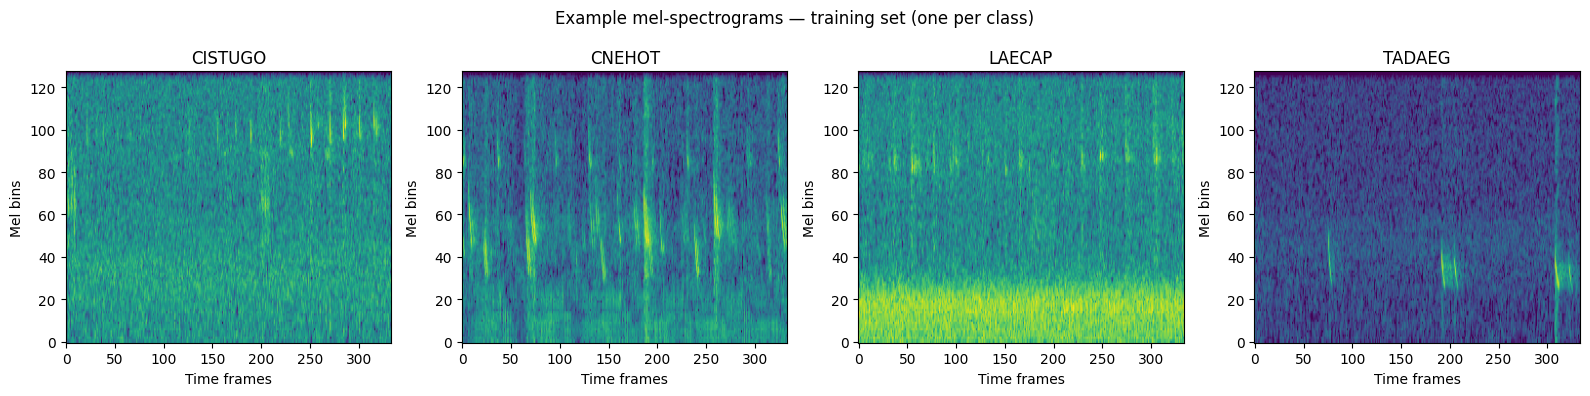

In [12]:
N_MELS=128

label_names = {v: k for k, v in creator.label_map.items()}
classes = sorted(creator.label_map.values())

fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 4))
for ax, cls_idx in zip(axes, classes):
    idxs = np.where(Y_train == cls_idx)[0]
    spec = X_train[idxs[0]] if len(idxs) > 0 else np.zeros((N_MELS, 1))
    ax.imshow(spec, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(label_names[cls_idx])
    ax.set_xlabel("Time frames")
    ax.set_ylabel("Mel bins")
plt.suptitle("Example mel-spectrograms — training set (one per class)")
plt.tight_layout()
plt.show()

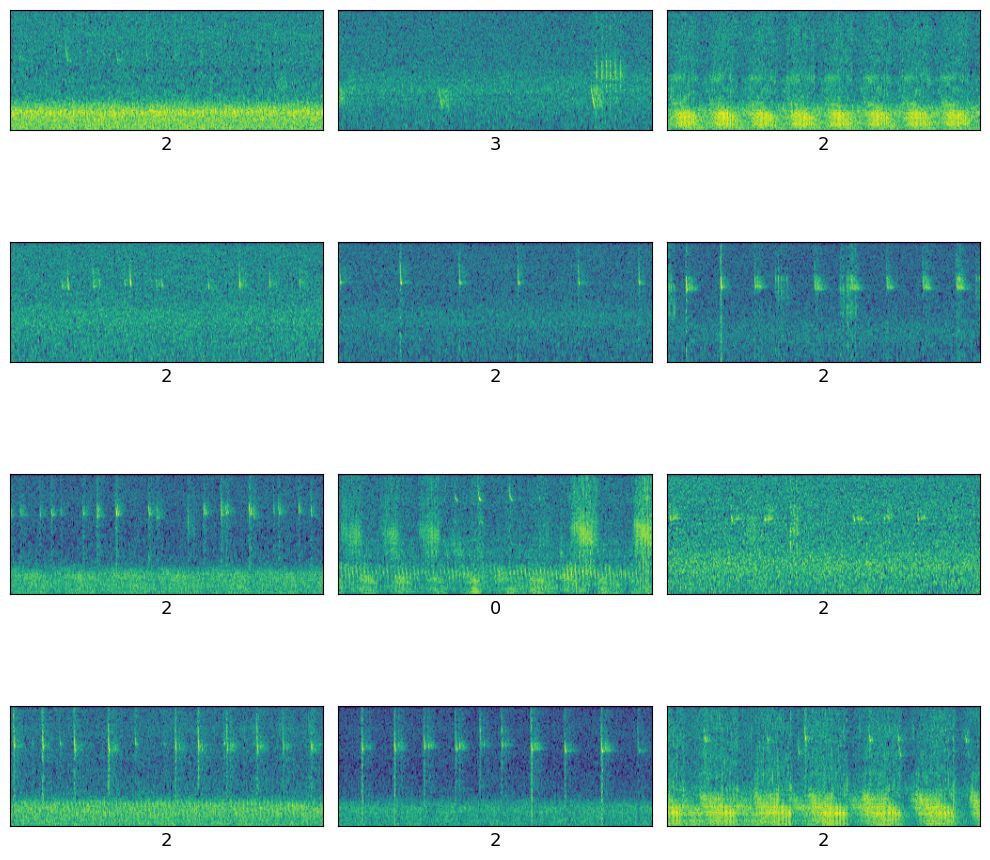

In [17]:
index=np.random.choice(len(X_test), size=12, replace=False)
fig = plt.figure(figsize=(10,10))
w=0
for i in index:
    plt.subplot(4,3,w+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test[i],  origin='lower')
    plt.xlabel(Y_test[i], fontsize=13)
    w+=1
plt.tight_layout()